# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'AppleGothic'   # Windows는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [4]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum()) # 변수별 결측치 개수
print(df.select_dtypes(include='number').agg(['min', 'max']))

(6000, 13)
customer_id            int64
age                    int64
gender                object
signup_channel        object
membership_tier       object
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group        object
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.
결측치는 없음, 고객 규모는 6000명이며 나이는 18~70세, 월 방문 횟수는 1~34회, 평균 적용 할인률은 0~0.5%, 온라인  광고비는 0.05~65.31, 오프라인 광고비는 0~39.38, 총 광고비는 0.59~68.28, 월 구매액은 8.26~288.44

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

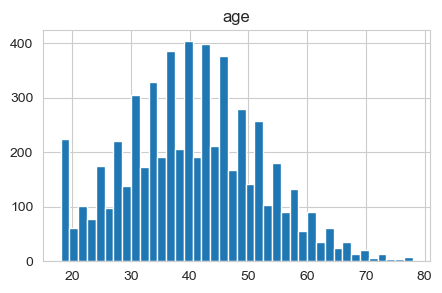

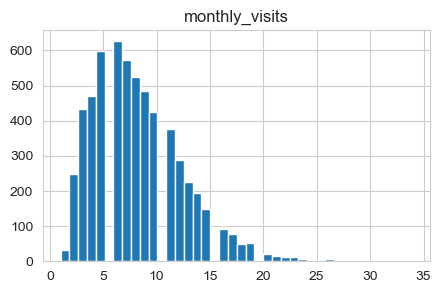

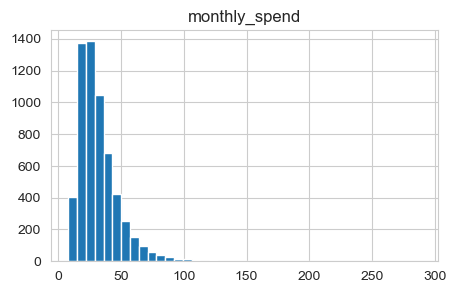

왜도 = 2.5456526289788064


c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


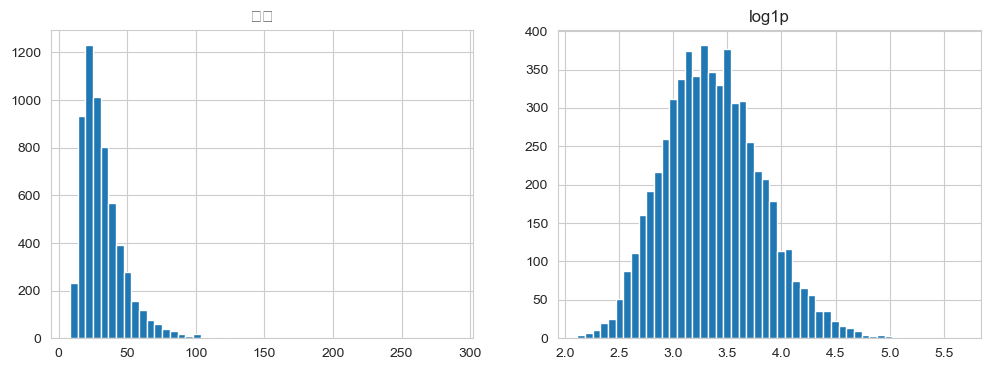

In [4]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew(numeric_only=True)   # 힌트: 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);          axes[0].set_title('원본')
axes[1].hist(np.log(df['monthly_spend']), bins=50)  
axes[1].set_title('log1p'); plt.show()

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요. 매출 분포(왼쪽)의 왜도는 약 2.5로 오른쪽으로 치우쳐 있는 우측 편향 그래프이다. x축이 300까지 이어져 있는 것으로 보아 소수의 고객이 매출을 많이 늘려주고, 마트에 잠깐 와서 25 정도만큼 쇼핑하는 고객이 대다수인 것으로 보인다. 로그 변환을 시행한 오른쪽 그래프는 비교적 정규분포의 형태에 더 가까우며 비정상적으로 큰 값들의 영향력이 줄어들어 분산이 안정화되었으므로, 이상치에 휘둘리지 않고 데이터의 전체적인 패턴을 훨씬 안정적으로 분석할 수 있는 장점이 있다.(정규성 가정이 필요한 분석들을 하기 좋아진다)

**3. 채널·등급별 매출 Boxplot**

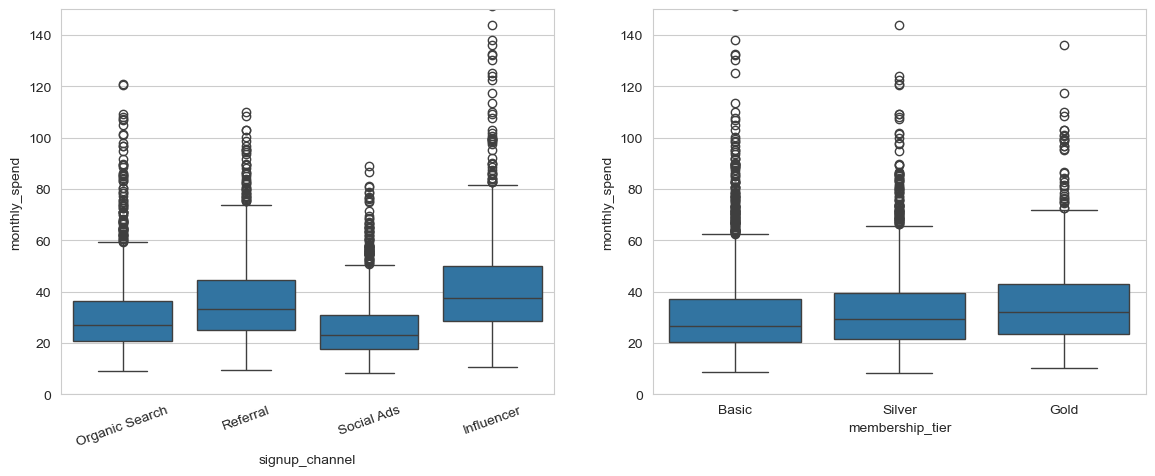

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요. 먼저 농산물 식재료를 검색해서 오거나 SNS 광고를 통해 유입된 고객층은 추천이나 인플루언서를 통해 유입된 고객층보다 중앙값, 박스가 아래에 있는 점을 고려했을 때 소비량이 비교적 낮다. 비슷하게, 멤버십 등급에도 비싼 멤버십일수록 박스가 서서히 올라가는 완만한 상승세를 보이고 있다. 하지만 인플루언서의 이상치(위에 찍힌 점)는 다른 3가지 유입경로보다 확실히 더 많은 모습을 보이지만 멤버십 등급의 이상치는 서로 비슷하게 분포되어 있는 점으로 보아 인플루언서 유입 고객은 고가치 고객이 되는 비율이 높다고 할 수 있으나 멤버십 등급에 따라 고가치 고객 수가 나뉜다고 할 수는 없을 것 같다.

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


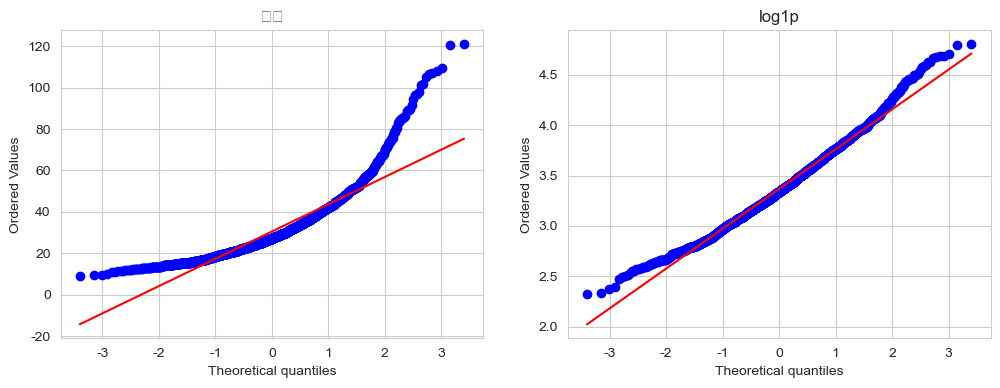

원본   ShapiroResult(statistic=np.float64(0.8534533976380867), pvalue=np.float64(3.631642400263992e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962407), pvalue=np.float64(0.00024486116128267225))


In [7]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))          # 힌트: shapiro
print('log1p ', stats.shapiro(np.log1p(xs)))

> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요. 귀무 가설: Organic search의 월 소비량 원본(로그변환) 데이터가 정규분포를 따른다. 두 가설들은 각각 pvalue가 3.63e-21, 0.0002로 0.05보다 훨씬 낮다. 따라서 귀무 가설을 기각할 충분한 근거가 있고, 엄밀하게 둘 다 정규분포를 따르지 않는다는 결론이 나온다. 하지만 검정통계량이 로그변환을 했을 때 0.98로 1에 훨씬 가까워졌고, pvalue도 많이 높아졌기 때문에 로그변환 후가 전보다 정규분포에 더 가까워진 것은 사실이다.

**6. 등분산성 검정**

In [5]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups) 
print('Levene p =', p)

Levene p = 4.335927248200273e-44


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요. p값이 0.05보다 엄청나게 작은 수가 나왔다. 이는 "귀무가설: 모든 그룹의 분산이 동일하다. (등분산성을 만족한다)" 를 기각할 수 있는 매우 강한 증거라는 뜻이고 4개 유입 경로에 따른 월 소비량 중 적어도 하나는 이분산성을 띤다는 의미이다.ANOVA에서 이분산성을 무시하고 검정을 진행하면  확률이 증가하게 된다. 실제로는 그룹 간 평균 차이가 없는데도 불구하고, 차이가 있다고 잘못된 결론을 내리는 1종 오류를 범할 확률이 크게 높아진다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [6]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']  
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)         
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.164492092129461e-19
t=-11.88 p=3.86e-32


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요. H0: 두 집단은 등분산성을 만족한다. H1: 등분산이 아니다. 르빈 검정 결과 pvalue<<0.05로 귀무 가설을 강한 근거로 기각할 수 있다. 따라서 이분산성을 띠는 두 집단에서 웰치스 분산분석을 진행한 결과, H0: ctrl과 trt 그룹 간 평균이 같다. H1: 그룹 간 평균이 다르다. 에서 매우 강한 근거로 귀무 가설을 기각할 수 있고 쿠폰을 발송한 그룹의 월 소비량이 더 많다는 결론이 나온다. 최종적으로, 캠페인을 지속하는 것이 이득이다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [7]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)  
print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요. H0: 4가지 그룹 간 평균의 차이가 없다. H1: 적어도 한 그룹은 평균이 다르다. 이 분산분석에서 p값이 2.67e-168으로 매우 강한 근거로 귀무 가설을 기각할 수 있다. 투키 사후분석에 의해, ads < organic < referral < influencer 순으로 모든 그룹에서 평균의 차이가 유의했으며 boxplot과 조합했을 때 인플루언서가 고가치 고객을, SNS 광고가 저가치 고객을 많이 데려오는 경향이 있다.

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [8]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요. 두 주효과 모두와 교호작용이 유의하다. 이는 월 소비량이 유입 경로와 캠페인 모두에 영향을 받으며, 유입 경로와 캠페인 간에 교호작용이 존재한다는 것을 뜻한다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [9]:
# 단순
m1 = smf.ols('monthly_spend ~monthly_visits', data=df).fit()   
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.053909275630528386


In [10]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)', data=df).fit()     #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        14:21:55   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나? 월 방문 수와 광고비의 계수는 0.xx인 데 비해 할인의 계수는 약 11.42로 매출에 유의미한 긍정적인 효과를 가진다. 할인을 확대하는 것은 일반적으로 좋은 전략이 될 수 있으나, 너무 할인하면 매출은 늘어나지만 순이익은 감소할 것이므로 적절한 균형점을 찾아야 할 것이다. 채널의 계수는 3가지 모두 음수인 결과를 보아, 위의 결과와 동일하게, 인플루언서를 제외한 3가지 그룹은 상대적으로 저가치 고객과 연관되어 있다는 것으로 해석할 수 있다. 마지막으로 결정 계수는 단순 회귀에 비해 커졌다. 이는 변수를 추가하면 결정 계수는 작아지지 않는다는 법칙의 실증 사례로 볼 수 있다.

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [11]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', 'total_ad_cost']] 
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


c:\Users\smmm1\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요. VIF는 1/1-R^2 (adjusted)로 계산되는데 총 광고비는 온라인과 오프라인 광고비의 합으로, 서로가 나머지 두 변수에 의해 설명되므로 결정 계수가 1이 되고 1/0을 하니까 값이 Inf가 나오는 것이다. 따라서 중복되는 변수인 총 광고비 변수를 제거함으로써 문제를 해결할 수 있다. 총 광고비 변수를 제거한 아래 VIF는 값들이 1 근처로 정상화된 것을 확인할 수 있다.

**12. 잔차 진단** (+ 로그변환 비교)

c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anacon

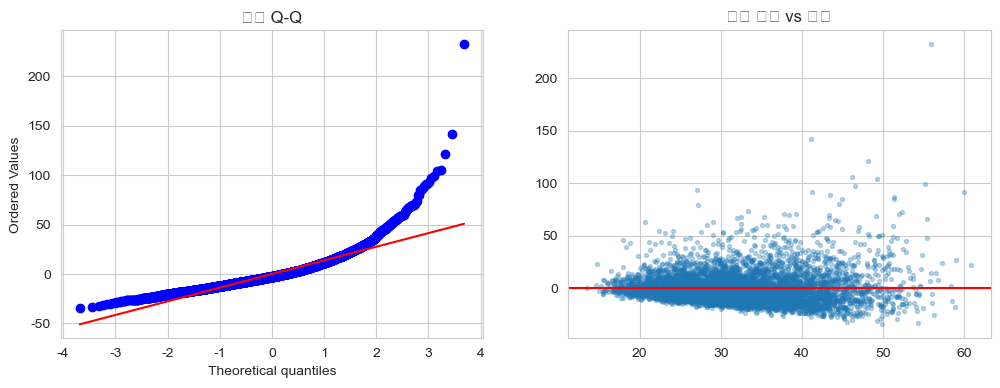

c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\smmm1\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


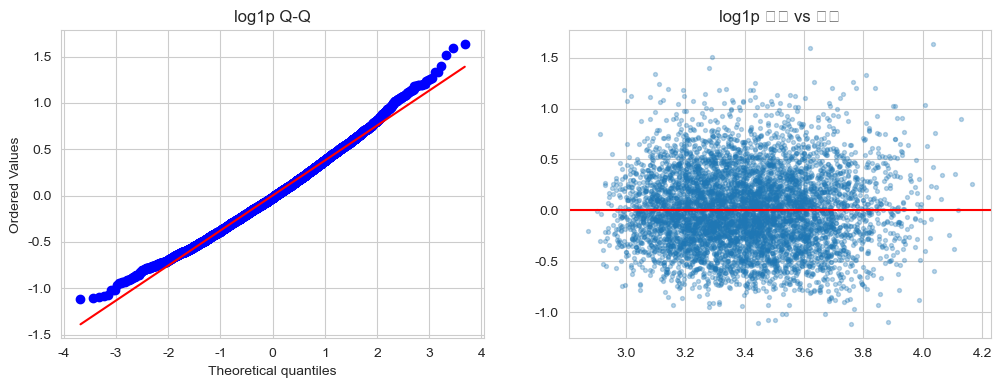

In [12]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요. 원본의 잔차는 x축에 따라 분산이 커지는 모습을 보였지만 로그 변환 이후에는 잔차의 분산이 일정해졌다.

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [13]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)})  
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Sat, 18 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        14:41:50   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요. 우선 반응에 대한 유의미한 긍정적 효과를 보이는 변수는 쿠폰 발송, 골드 멤버십, 실버 멤버십 정도가 있고 오즈비는 쿠폰 발송, 골드, 실버 멤버십이 각각 2.4, 2, 1.4로 유의미한 반응률 증가를 보이고 있다. 따라서 다음 캠페인에는 골드, 실버 멤버십 고객들에게 쿠폰을 제공할 때 가장 좋은 반응률을 기대할 수 있을 것이다.

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)